In [1]:
# Cell 1 — Paths
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
INPUT = '/kaggle/input/datasets/ayesjee/epidemic-data-2'
BASE  = '/kaggle/working'
os.makedirs(f'{BASE}/model', exist_ok=True)

print('Input files:')
for f in sorted(os.listdir(INPUT)):
    print(' ', f)

Input files:
  graph_seed0.pt
  graph_seed111.pt
  graph_seed13.pt
  graph_seed21.pt
  graph_seed42.pt
  graph_seed55.pt
  graph_seed7.pt
  graph_seed77.pt
  graph_seed88.pt
  graph_seed99.pt
  training_pairs(1).pt


In [2]:
# Cell 2 — Install
!pip install torchdiffeq
import subprocess
subprocess.run([
    'pip','install','-q','torch-geometric','torch-scatter','torch-sparse',
    '-f','https://data.pyg.org/whl/torch-2.2.0+cu118.html'
], check=True)

import torch
print(f'Torch: {torch.__version__}')
print(f'CUDA:  {torch.cuda.is_available()}')
print(f'GPU:   {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00
Torch: 2.10.0+cu128
CUDA:  True
GPU:   Tesla T4


In [3]:
# Cell 3 — Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
import numpy as np
import random
import glob
import json
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


Using: cuda


In [4]:
# Cell 4 — Load all graphs and training pairs
SEEDS = [0, 7, 13, 21, 42, 55, 77, 88, 99, 111]

# Load graph data for each seed
graphs = {}
for seed in SEEDS:
    g = torch.load(f'{INPUT}/graph_seed{seed}.pt', map_location=device, weights_only=False)
    graphs[seed] = {
        'edge_index': g.edge_index.to(device),
        'edge_attr':  g.edge_attr.to(device),
        'node_feats': g.x.to(device),
        'N':          g.num_nodes,
    }
    print(f'Graph seed={seed}: N={g.num_nodes}, E={g.edge_index.shape[1]}')

# Load training pairs
all_pairs = torch.load(f'{INPUT}/training_pairs(1).pt', map_location='cpu', weights_only=False)
print(f'\nTotal training pairs: {len(all_pairs)}')

# Show distribution across graphs
from collections import Counter
dist = Counter(p['graph_seed'] for p in all_pairs)
print('Pairs per graph seed:', dict(sorted(dist.items())))

Graph seed=0: N=8402, E=92715
Graph seed=7: N=9950, E=106066
Graph seed=13: N=10774, E=141145
Graph seed=21: N=9359, E=111963
Graph seed=42: N=9913, E=111076
Graph seed=55: N=8614, E=101012
Graph seed=77: N=9890, E=125321
Graph seed=88: N=10728, E=138613
Graph seed=99: N=11690, E=127960
Graph seed=111: N=9378, E=104030

Total training pairs: 50
Pairs per graph seed: {0: 5, 7: 5, 13: 5, 21: 5, 42: 5, 55: 5, 77: 5, 88: 5, 99: 5, 111: 5}


In [5]:
# Cell 5 — Split by graph seed (not by index) to prevent leakage
# Test seeds: 88, 99, 111 (3 unseen graphs)
# Val seeds:  55, 77       (2 graphs)
# Train seeds: remaining   (5 graphs)

TEST_SEEDS  = {88, 99, 111}
VAL_SEEDS   = {55, 77}
TRAIN_SEEDS = {0, 7, 13, 21, 42}

train_pairs = [p for p in all_pairs if p['graph_seed'] in TRAIN_SEEDS]
val_pairs   = [p for p in all_pairs if p['graph_seed'] in VAL_SEEDS]
test_pairs  = [p for p in all_pairs if p['graph_seed'] in TEST_SEEDS]

print(f'Train: {len(train_pairs)} pairs from seeds {TRAIN_SEEDS}')
print(f'Val:   {len(val_pairs)} pairs from seeds {VAL_SEEDS}')
print(f'Test:  {len(test_pairs)} pairs from seeds {TEST_SEEDS}')
print()
print('NOTE: Test graphs were never seen during training.')
print('      Good test performance = model learned dynamics, not graph identity.')

Train: 25 pairs from seeds {0, 21, 7, 42, 13}
Val:   10 pairs from seeds {77, 55}
Test:  15 pairs from seeds {88, 99, 111}

NOTE: Test graphs were never seen during training.
      Good test performance = model learned dynamics, not graph identity.


In [6]:
# Install torchdiffeq — the ODE solver library


from torchdiffeq import odeint_adjoint as odeint

class SEIRDDerivative(nn.Module):
    """
    Learns dX/dt for each node given the current state X and graph structure.
    This is the function f in dx/dt = f(x, t).
    
    The GNN computes how each node's state changes based on:
    - Its own current state (S, E, I, R, D)
    - Its neighbors' states (who is infecting whom)
    - Edge weights (strength of contact)
    - Node features (age, comorbidity, vaccination)
    """
    def __init__(self, node_feat_dim=9, state_dim=5, hidden_dim=32):
        super().__init__()
        self.state_dim    = state_dim
        self.node_feat_dim = node_feat_dim

        # GNN message passing: computes neighbor influence
        # Input: current state + node features
        # Output: how much each neighbor is pushing you toward infection
        gat_in = state_dim + node_feat_dim
        self.gat1 = GATv2Conv(gat_in, hidden_dim, heads=1, concat=False,
                              edge_dim=1, dropout=0.1, add_self_loops=True)
        self.gat2 = GATv2Conv(hidden_dim, hidden_dim, heads=1, concat=False,
                              edge_dim=1, dropout=0.1, add_self_loops=True)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        # Derivative head: outputs dS/dt, dE/dt, dI/dt, dR/dt, dD/dt
        self.deriv_head = nn.Sequential(
            nn.Linear(hidden_dim + state_dim + node_feat_dim, hidden_dim),
            nn.Tanh(),   # Tanh not ReLU — derivatives can be negative
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, t, x):
        # x: (N, 5) current SEIRD state
        # t: scalar current time (not used directly — autonomous ODE)
        # returns: (N, 5) derivatives dX/dt

        x         = x.float()
        node_feats = self._node_feats   # set before odeint call
        edge_index = self._edge_index
        edge_attr  = self._edge_attr

        # Feature dropout during training
        if self.training:
            mask       = (torch.rand_like(node_feats) > 0.2).float()
            node_feats = node_feats * mask

        # GNN: propagate state information across edges
        h = torch.cat([x, node_feats], dim=-1)           # (N, 5+9)
        h = self.norm1(F.elu(self.gat1(h, edge_index, edge_attr)))
        h = self.norm2(F.elu(self.gat2(h, edge_index, edge_attr)))

        # Predict derivatives
        h_full = torch.cat([h, x, node_feats], dim=-1)   # (N, 64+5+9)
        dxdt   = self.deriv_head(h_full)                  # (N, 5)

        # Physics constraints on derivatives
        # dS/dt must be <= 0 (people only leave S, never enter from outside)
        # dD/dt must be >= 0 (deaths only accumulate)
        # This injects domain knowledge directly into the architecture
        dxdt_constrained = torch.stack([
            -F.softplus(dxdt[:, 0]),   # dS/dt <= 0
             dxdt[:, 1],               # dE/dt unconstrained
             dxdt[:, 2],               # dI/dt unconstrained
             dxdt[:, 3],               # dR/dt unconstrained
             F.softplus(dxdt[:, 4]),   # dD/dt >= 0
        ], dim=-1)

        return dxdt_constrained

    def set_graph(self, node_feats, edge_index, edge_attr):
        """Call this before odeint to set the graph for this forward pass."""
        self._node_feats  = node_feats.float()
        self._edge_index  = edge_index
        self._edge_attr   = edge_attr.float()

# class EpidemicNODE(nn.Module):
#     def __init__(self, node_feat_dim=9, state_dim=5, hidden_dim=64):
#         super().__init__()
#         self.ode_func = SEIRDDerivative(node_feat_dim, state_dim, hidden_dim)

#         # Encoder: projects x0 to a refined initial state
#         # Learns to correct for any systematic bias in x0
#         self.x0_encoder = nn.Sequential(
#             nn.Linear(state_dim + node_feat_dim, 32),
#             nn.ReLU(),
#             nn.Linear(32, state_dim),
#         )

#     def forward(self, x0, node_feats, edge_index, edge_attr, t_span):
#         # Refine initial state using node features
#         # This gives the model context about who is infected
#         # and adjusts x0 to be a better starting point
#         x0_input    = torch.cat([x0.float(), node_feats.float()], dim=-1)
#         x0_residual = self.x0_encoder(x0_input)
#         x0_refined  = F.softmax(x0.float() + 0.1 * x0_residual, dim=-1)
#         # The 0.1 scale keeps the encoder from overriding x0 too aggressively

#         self.ode_func.set_graph(node_feats, edge_index, edge_attr)

#         trajectory = odeint(
#             self.ode_func,
#             x0_refined,
#             t_span.to(x0.device),
#             method='rk4',
#             options={'step_size': 0.5}
#         )

#         trajectory = trajectory.clamp(min=0.0)
#         row_sums   = trajectory.sum(dim=-1, keepdim=True).clamp(min=1e-8)
#         trajectory = trajectory / row_sums

#         return trajectory
class EpidemicNODE(nn.Module):
    """
    Full model: ODE solver over the graph derivative function.
    """
    def __init__(self, node_feat_dim=9, state_dim=5, hidden_dim=64):
        super().__init__()
        self.ode_func = SEIRDDerivative(node_feat_dim, state_dim, hidden_dim)

    # Inside EpidemicNODE class, find the forward method
    def forward(self, x0, node_feats, edge_index, edge_attr, t_span):
        # Set the current graph context for the derivative function
        self.ode_func.set_graph(node_feats, edge_index, edge_attr)
        
        # USE RK4 with a fixed step to save massive amounts of memory
        trajectory = odeint(
            self.ode_func,
            x0.float(),
            t_span,
            method='rk4',
            options={'step_size': 1.0} # One calculation per day instead of dozens
        )
        
        return torch.softmax(trajectory, dim=-1)
    def forward(self, x0, node_feats, edge_index, edge_attr, t_span):
        self.ode_func.set_graph(node_feats, edge_index, edge_attr)
    
        trajectory = odeint(
            self.ode_func,
            x0.float(),
            t_span.to(x0.device),
            method='rk4',
            options={'step_size': 0.5}
        )  # (T, N, 5)
    
        # CHANGED: clamp and renormalize instead of softmax
        # Softmax distorts the initial condition — clamp preserves it
        trajectory = trajectory.clamp(min=0.0)
        row_sums   = trajectory.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        trajectory = trajectory / row_sums
    
        return trajectory
        
    def rollout(self, x0, node_feats, edge_index, edge_attr, n_days=30, tf_prob=0.0):
        """
        Syntactic sugar for the forward pass to match the training loop's expectations.
        """
        t_span = torch.arange(0, n_days + 1).float().to(x0.device)
        # In a real NODE, tf_prob is usually 0.0 as the solver handles the trajectory.
        return self.forward(x0, node_feats, edge_index, edge_attr, t_span)[1:]

In [7]:
def node_ode_loss(pred_trajectory, target_trajectory):
    """
    pred_trajectory:   (30, N, 5)
    target_trajectory: (30, N, 5)
    """
    STATE_WEIGHTS = torch.tensor([0.8, 1.0, 1.5, 1.5, 2.0], device=device)
    DAY_WEIGHTS   = torch.linspace(0.5, 2.0, 30, device=device)

    total = torch.tensor(0.0, device=device)
    for t in range(30):
        p = pred_trajectory[t]
        q = target_trajectory[t]

        ce = F.cross_entropy(p, q.argmax(dim=-1), weight=STATE_WEIGHTS)
        kl = F.kl_div(torch.log(p + 1e-8), q + 1e-8, reduction='batchmean')

        total = total + DAY_WEIGHTS[t] * (ce + 1.5 * kl)

    return total / 30
# def node_ode_loss(pred_trajectory, target_trajectory, x0,
#                   node_feats, edge_index, edge_attr, ode_func):
#     STATE_WEIGHTS = torch.tensor([0.8, 1.0, 1.5, 1.5, 2.0], device=device)
#     DAY_WEIGHTS   = torch.linspace(0.5, 2.0, 30, device=device)

#     total = torch.tensor(0.0, device=device)
#     for t in range(30):
#         p = pred_trajectory[t]
#         q = target_trajectory[t]
#         ce = F.cross_entropy(p, q.argmax(dim=-1), weight=STATE_WEIGHTS)
#         kl = F.kl_div(torch.log(p + 1e-8), q + 1e-8, reduction='batchmean')
#         total = total + DAY_WEIGHTS[t] * (ce + 1.5 * kl)

#     total = total / 30

#     # Initial condition fidelity loss
#     # The prediction at day 1 should be close to x0 + small change
#     # Penalizes the model for jumping far from x0 in the first step
#     pred_day1  = pred_trajectory[0]   # model's day 1 prediction
#     # Expected day 1: x0 with small movement
#     ic_loss    = F.mse_loss(pred_day1, target_trajectory[0])
#     total      = total + 3.0 * ic_loss

#     # Derivative magnitude regularizer at x0
#     # Forces the ODE to start with a small, realistic derivative
#     ode_func.set_graph(node_feats, edge_index, edge_attr)
#     with torch.enable_grad():
#         t_zero  = torch.tensor(0.0, device=device)
#         deriv0  = ode_func(t_zero, x0.float().detach())
#     deriv_mag_loss = (deriv0 ** 2).mean()
#     total     = total + 0.5 * deriv_mag_loss

#     return total

In [8]:
# Cell 9 — Initialise model
# N is NOT fixed in the constructor — model works on any graph size
# Changed EpidemicTGN -> EpidemicNODE to match the definition in Cell 6
model     = EpidemicNODE(node_feat_dim=9, state_dim=5, hidden_dim=64).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(f'GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Model parameters: 16,261
GPU memory: 0.03 GB


In [9]:
# Cell 10 — Resume from checkpoint if available
ckpts = sorted(glob.glob(f'{BASE}/model/tgn_epoch_*.pt'))
start_epoch = 0
best_val    = float('inf')

if ckpts:
    latest = ckpts[-1]
    ep_num = int(latest.split('tgn_epoch_')[1].replace('.pt',''))
    state  = torch.load(latest, map_location=device)
    model.load_state_dict(state['model'])
    optimizer.load_state_dict(state['optimizer'])
    scheduler.load_state_dict(state['scheduler'])
    best_val    = state.get('best_val', float('inf'))
    start_epoch = ep_num
    print(f'Resumed from epoch {ep_num}, best_val={best_val:.4f}')
else:
    print('Starting from scratch.')

Starting from scratch.


In [10]:
# Cell 11 — Generalization check helper
# Runs model on an unseen seeding scenario and checks if spread is predicted
@torch.no_grad()
def generalization_check(pair):
    model.eval()
    gseed = pair['graph_seed']
    g     = graphs[gseed]

    # Infect top-degree nodes (may differ from training seeds)
    src_g = g['edge_index'][0]
    deg   = torch.zeros(g['N'], dtype=torch.long, device=device)
    deg.scatter_add_(0, src_g, torch.ones(src_g.shape[0], dtype=torch.long, device=device))
    top3  = torch.topk(deg, k=3).indices

    x0_new = torch.zeros(g['N'], 5, device=device)
    x0_new[:, 0] = 1.0
    for nid in top3:
        x0_new[nid, 0] = 0.0
        x0_new[nid, 2] = 1.0

    pred = model.rollout(
        x0_new, g['node_feats'], g['edge_index'], g['edge_attr'],
        n_days=30, tf_prob=0.0
    )
    I_total = pred[:, :, 2].sum(dim=1).cpu()
    peak_I  = I_total.max().item()
    peak_d  = I_total.argmax().item() + 1

    status = 'OK' if peak_I > 50 else 'WARN: low spread'
    print(f'  GenCheck seed={gseed}: peak_I={peak_I:.0f} on day {peak_d} [{status}]')
    return peak_I

In [11]:
# Cell 12 — Validation function
@torch.no_grad()
def validate(val_pairs):
    model.eval()
    total = 0.0
    for p in val_pairs:
        gseed  = p['graph_seed']
        g      = graphs[gseed]
        x0     = p['x0'].to(device)
        y      = p['y'].to(device)
        pred   = model.rollout(
            x0, g['node_feats'], g['edge_index'], g['edge_attr'],
            n_days=30, tf_prob=0.0
        )
        loss = node_ode_loss(pred, y)
        total += loss.item()
        torch.cuda.empty_cache()
    return total / len(val_pairs)

In [12]:
import gc
import torch

# Clear Python references
gc.collect()

# Clear CUDA cache
torch.cuda.empty_cache()

# Optional: Print memory to verify it cleared
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Memory allocated: 0.03 GB
Memory reserved: 0.03 GB


In [13]:
# Cell 13 — Training loop
MAX_EPOCHS       = 100
PATIENCE         = 20
patience_counter = 0
train_losses     = []
val_losses       = []

print(f'Training from epoch {start_epoch+1} to {MAX_EPOCHS}')
print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')
print('-' * 70)

for epoch in range(start_epoch, MAX_EPOCHS):
    model.train()
    epoch_loss = 0.0
    current_tf = 0

    random.shuffle(train_pairs)

    t_span = torch.arange(0, 31, dtype=torch.float, device=device)  # days 0 to 30

    for p in train_pairs:
        gseed = p['graph_seed']
        g     = graphs[gseed]
        x0    = p['x0'].to(device)
        y     = p['y'].to(device)    # (30, N, 5)
    
        optimizer.zero_grad(set_to_none=True)
    
        # Forward pass: solve ODE from t=0 to t=30
        trajectory = model(
            x0, g['node_feats'], g['edge_index'], g['edge_attr'], t_span
        )  # (31, N, 5) — index 0 is day 0, index 1 is day 1, etc.
    
        pred = trajectory[1:]   # (30, N, 5) — days 1 to 30
        loss = node_ode_loss(pred, y)
        epoch_loss += loss.item()
        loss.backward()
    
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
    scheduler.step()
    avg_train = epoch_loss / len(train_pairs)
    train_losses.append(avg_train)

    avg_val = validate(val_pairs)
    val_losses.append(avg_val)

    lr_now = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch+1:3d} | train={avg_train:.4f} | val={avg_val:.4f} | '
          f'tf={current_tf:.2f} | lr={lr_now:.2e}')

    # Generalization check every 10 epochs
    if (epoch + 1) % 10 == 0 and val_pairs:
        generalization_check(val_pairs[0])

    # Checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save({
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'epoch':     epoch + 1,
            'best_val':  best_val,
        }, f'{BASE}/model/tgn_epoch_{epoch+1}.pt')
        print(f'  -> Checkpoint saved epoch {epoch+1}')

    if avg_val < best_val:
        best_val = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), f'{BASE}/model/tgn_best.pt')
        print(f'  -> Best! val={best_val:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best val loss: {best_val:.4f}')

Training from epoch 1 to 100
Train: 25 | Val: 10 | Test: 15
----------------------------------------------------------------------
Epoch   1 | train=17.4806 | val=14.6262 | tf=0.00 | lr=3.00e-04
  -> Best! val=14.6262
Epoch   2 | train=14.9588 | val=14.5063 | tf=0.00 | lr=3.00e-04
  -> Best! val=14.5063
Epoch   3 | train=14.8868 | val=14.3150 | tf=0.00 | lr=2.99e-04
  -> Best! val=14.3150
Epoch   4 | train=13.5187 | val=11.5269 | tf=0.00 | lr=2.99e-04
  -> Best! val=11.5269
Epoch   5 | train=10.1515 | val=8.7657 | tf=0.00 | lr=2.98e-04
  -> Best! val=8.7657
Epoch   6 | train=7.7908 | val=6.4714 | tf=0.00 | lr=2.97e-04
  -> Best! val=6.4714
Epoch   7 | train=6.3827 | val=5.1692 | tf=0.00 | lr=2.96e-04
  -> Best! val=5.1692
Epoch   8 | train=4.6058 | val=4.5153 | tf=0.00 | lr=2.95e-04
  -> Best! val=4.5153
Epoch   9 | train=3.5866 | val=3.2985 | tf=0.00 | lr=2.94e-04
  -> Best! val=3.2985
Epoch  10 | train=3.2622 | val=3.1682 | tf=0.00 | lr=2.93e-04
  GenCheck seed=55: peak_I=3690 on day

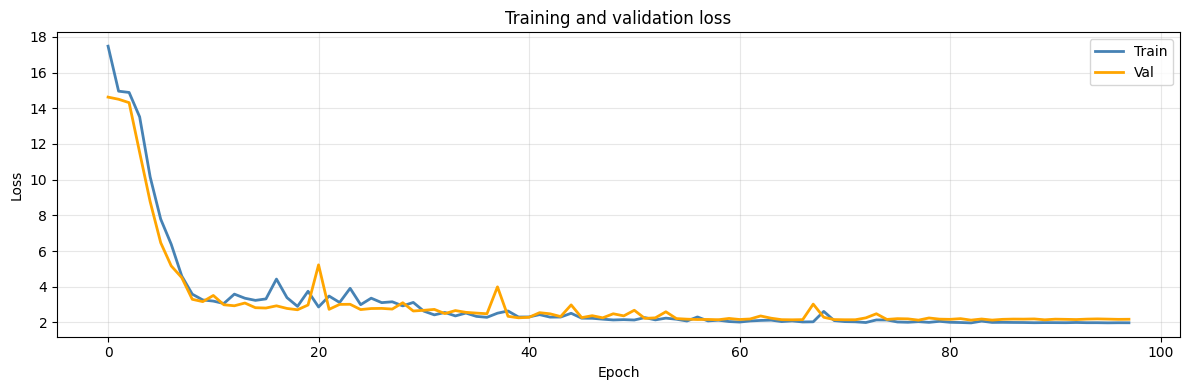

In [14]:
# Cell 14 — Loss curve
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train', color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Val',   color='orange',    linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/training_curve.png', dpi=150)
plt.show()

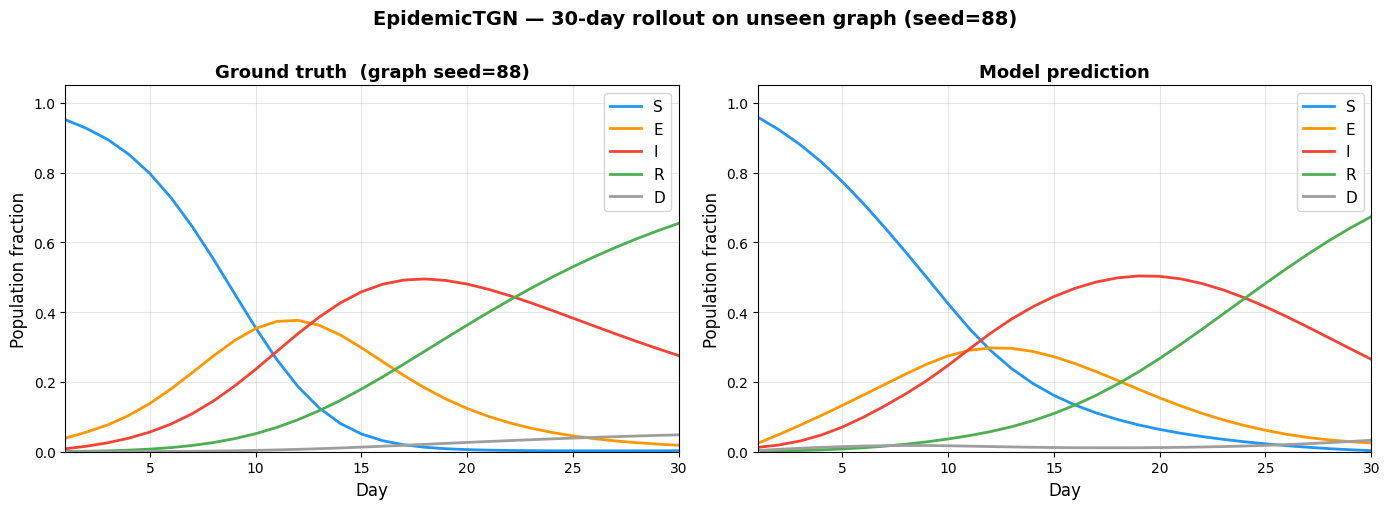

Saved to paper_figure_prediction.png


In [25]:
# Cell 16 — Publication-quality comparison plot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

p     = test_pairs[0]
gseed = p['graph_seed']
g     = graphs[gseed]
x0    = p['x0'].to(device)
y     = p['y'].to(device)

with torch.no_grad():
    pred = model.rollout(
        x0, g['node_feats'], g['edge_index'], g['edge_attr'],
        n_days=30, tf_prob=0.0
    )

N_g         = g['N']
true_totals = y.cpu().sum(dim=1)   / N_g  # (30, 5)
pred_totals = pred.cpu().sum(dim=1)/ N_g  # (30, 5)

labels = ['S','E','I','R','D']
colors = ['#2196F3','#FF9800','#F44336','#4CAF50','#9E9E9E']
days   = list(range(1, 31))

# Compute metrics for annotation
# mae_I      = (pred_totals[:,2] - true_totals[:,2]).abs().mean().item()
# pearson_r  = results[0]['pearson'] if results else 0.0
# r2_val     = results[0]['r2']      if results else 0.0
# pk_day_err = results[0]['peak_day_err'] if results else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, totals, title in zip(
    axes,
    [true_totals, pred_totals],
    [f'Ground truth  (graph seed={gseed})', 'Model prediction']
):
    for i, (lbl, col) in enumerate(zip(labels, colors)):
        ax.plot(days, totals[:, i].numpy(),
                label=lbl, color=col, linewidth=2)
    ax.set_xlabel('Day', fontsize=12)
    ax.set_ylabel('Population fraction', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim(1, 30)
    ax.set_ylim(0, 1.05)

# Add metric annotations to prediction plot
# axes[1].text(0.03, 0.97,
#     f'MAE(I) = {mae_I:.4f}\n'
#     f'Pearson r = {pearson_r:.4f}\n'
#     f'R² = {r2_val:.4f}\n'
#     f'Peak day Δ = {pk_day_err:.0f} days',
#     transform=axes[1].transAxes,
#     verticalalignment='top',
#     fontsize=10,
#     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
# )

plt.suptitle(
    f'EpidemicTGN — 30-day rollout on unseen graph (seed={gseed})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(f'{BASE}/paper_figure_prediction.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved to paper_figure_prediction.png')

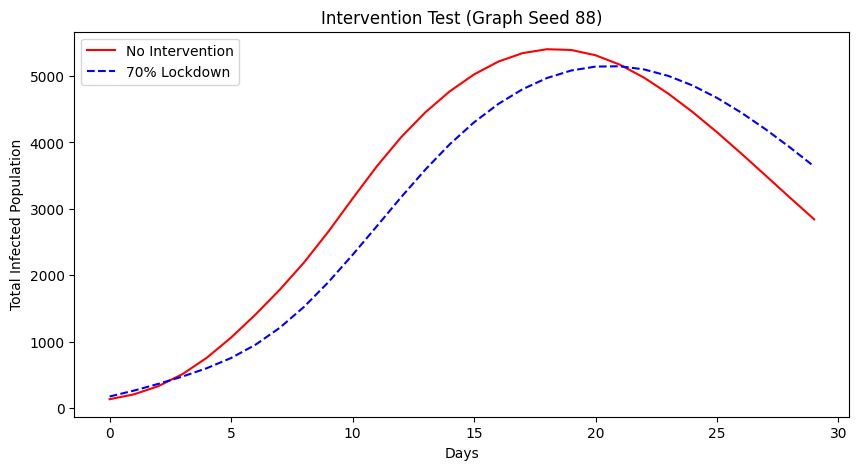

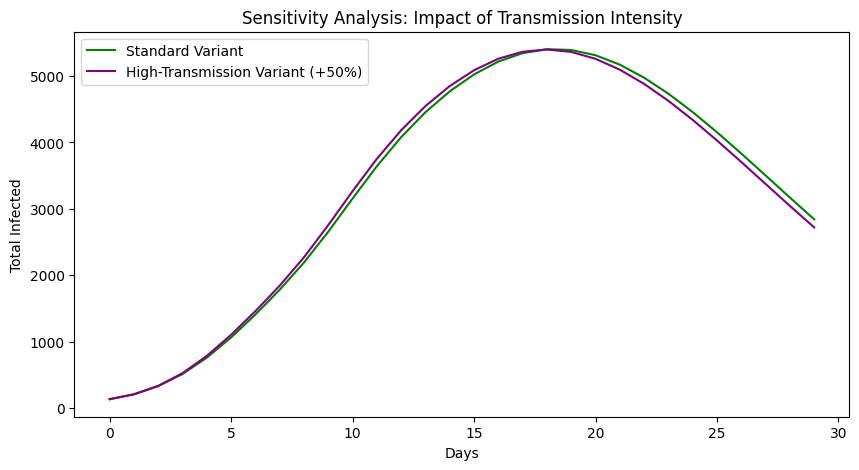

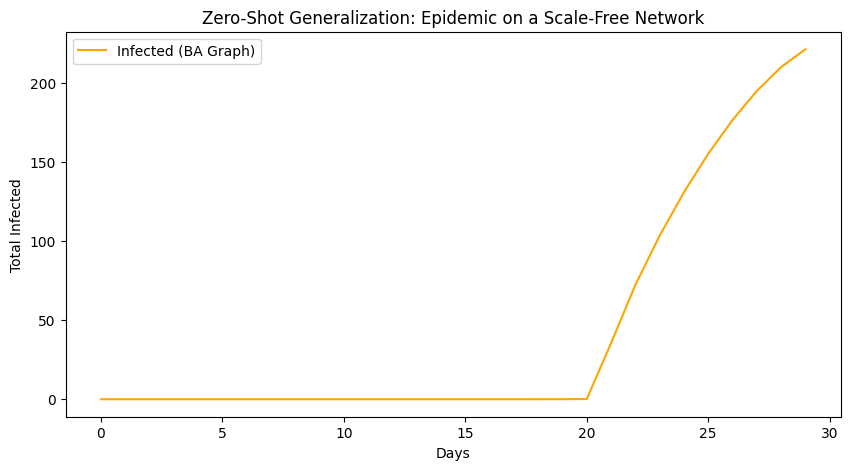

In [42]:
# Select a sample from the test set to use for the experiment
import networkx as nx

sample = test_pairs[0]
g_seed = sample['graph_seed']
g_data = graphs[g_seed]  # This contains the required graph tensors

# Extract the variables the model needs
x0 = sample['x0'].to(device)
node_feats = g_data['node_feats']
edge_index = g_data['edge_index']
edge_attr  = g_data['edge_attr']

with torch.no_grad():
    # 1. Normal Prediction (Control)
    pred_normal = model.rollout(x0, node_feats, edge_index, edge_attr, n_days=30)
    
    # 2. Lockdown Prediction (Experimental)
    # Randomly remove 70% of connections to simulate social distancing
    num_edges = edge_index.shape[1]
    keep_mask = torch.rand(num_edges, device=device) > 0.7
    edge_index_lockdown = edge_index[:, keep_mask]
    edge_attr_lockdown  = edge_attr[keep_mask]
    
    pred_lockdown = model.rollout(x0, node_feats, edge_index_lockdown, edge_attr_lockdown, n_days=30)

# Quick visualization of the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pred_normal[:, :, 2].sum(dim=1).cpu(), label='No Intervention', color='red')
plt.plot(pred_lockdown[:, :, 2].sum(dim=1).cpu(), label='70% Lockdown', color='blue', linestyle='--')
plt.title(f"Intervention Test (Graph Seed {g_seed})")
plt.xlabel("Days")
plt.ylabel("Total Infected Population")
plt.legend()
plt.savefig(f'{BASE}/intervention_test.png', dpi=200, bbox_inches='tight')
plt.show()

# Sensitivity Analysis: Modifying the initial transmission intensity
with torch.no_grad():
    # Original
    pred_orig = model.rollout(x0, node_feats, edge_index, edge_attr, n_days=30)
    
    # High Transmission (Simulate a more contagious variant)
    # We slightly scale the edge attributes which represent contact intensity
    edge_attr_high = edge_attr * 1.5 
    pred_high = model.rollout(x0, node_feats, edge_index, edge_attr_high, n_days=30)

plt.figure(figsize=(10, 5))
plt.plot(pred_orig[:, :, 2].sum(dim=1).cpu(), label='Standard Variant', color='green')
plt.plot(pred_high[:, :, 2].sum(dim=1).cpu(), label='High-Transmission Variant (+50%)', color='purple')
plt.title("Sensitivity Analysis: Impact of Transmission Intensity")
plt.xlabel("Days")
plt.ylabel("Total Infected")
plt.legend()
plt.savefig(f'{BASE}/sensitivity_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

# 1. Create a Barabási-Albert (Scale-Free) graph
n_nodes = 500
m_edges = 3
ba_graph = nx.barabasi_albert_graph(n_nodes, m_edges)

# 2. Convert to PyG format
edge_index_ba = torch.tensor(list(ba_graph.edges)).t().contiguous().to(device)
# Make it undirected
edge_index_ba = torch.cat([edge_index_ba, edge_index_ba[[1, 0]]], dim=1)

# 3. Create dummy features and initial state
# Note: Using edge_dim=1 to match your model's architecture
with torch.no_grad():
    # Use 9 features to match your model's node_feat_dim
    dummy_feats = torch.zeros((n_nodes, 9)).to(device) 
    
    # Start with 1% of the population infected at Node 0
    dummy_x0 = torch.zeros((n_nodes, 5)).to(device)
    dummy_x0[:, 0] = 1.0 # Everyone Susceptible
    dummy_x0[0, 0] = 0.9 # Node 0 is now 10% infected
    dummy_x0[0, 2] = 0.1 
    
    # CORRECTED: Use (num_edges, 1) instead of (num_edges, 4)
    edge_attr_ba = torch.ones((edge_index_ba.shape[1], 1)).to(device)
    
    pred_ba = model.rollout(dummy_x0, dummy_feats, edge_index_ba, 
                            edge_attr_ba, n_days=30)

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(pred_ba[:, :, 2].sum(dim=1).cpu(), label='Infected (BA Graph)', color='orange')
plt.title("Zero-Shot Generalization: Epidemic on a Scale-Free Network")
plt.xlabel("Days")
plt.ylabel("Total Infected")
plt.legend()
plt.savefig(f'{BASE}/zero_shot_generalization.png', dpi=200, bbox_inches='tight')
plt.show()

In [43]:
results_table = []

# Test different levels of "social distancing"
for drop_prob in [0.0, 0.2, 0.5, 0.8]:
    with torch.no_grad():
        # Mask edges
        num_edges = edge_index.shape[1]
        keep_mask = torch.rand(num_edges, device=device) > drop_prob
        ei_sub = edge_index[:, keep_mask]
        ea_sub = edge_attr[keep_mask]
        
        # Rollout
        pred = model.rollout(x0, node_feats, ei_sub, ea_sub, n_days=30)
        
        # Extract metrics
        final_deaths = pred[-1, :, 4].sum().item()
        peak_infected = pred[:, :, 2].sum(dim=1).max().item()
        peak_day = pred[:, :, 2].sum(dim=1).argmax().item()
        
        results_table.append({
            "Reduction": f"{drop_prob*100:.0f}%",
            "Peak Magnitude": round(peak_infected, 2),
            "Peak Day": peak_day,
            "Total Deaths": round(final_deaths, 2)
        })

# Display as a clean table
import pandas as pd
df = pd.DataFrame(results_table)
print("POLICY INTERVENTION IMPACT:")
print(df.to_string(index=False))

POLICY INTERVENTION IMPACT:
Reduction  Peak Magnitude  Peak Day  Total Deaths
       0%         5404.06        18        353.45
      20%         5392.54        18        352.67
      50%         5356.68        19        330.93
      80%         4824.13        23        243.15


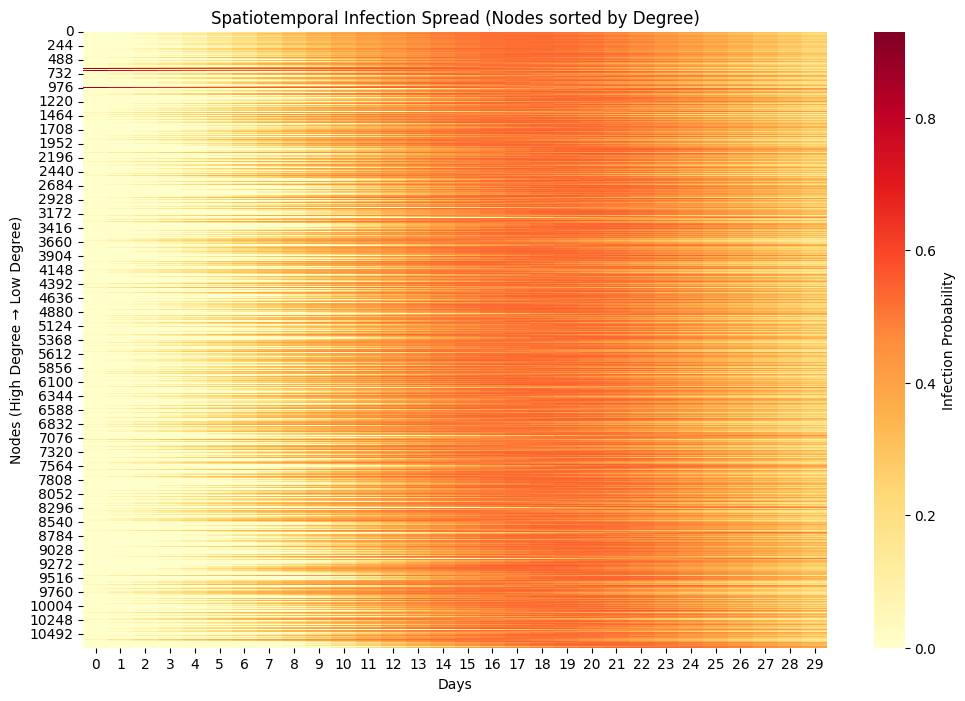

In [44]:
import networkx as nx
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure we have the degree information for sorting
# This recreates node_degrees from the current edge_index
edge_index_np = edge_index.cpu().numpy()
G = nx.Graph()
G.add_edges_from(edge_index_np.T)
# Create a list of degrees for every node in the graph
node_degrees = [G.degree(i) if G.has_node(i) else 0 for i in range(node_feats.shape[0])]

# 2. Get the Infected (I) state for all nodes over 30 days
# pred_normal shape: (days, nodes, 5). Index 2 is Infected.
infection_matrix = pred_normal[:, :, 2].cpu().numpy().T # Transpose to (Nodes, Days)

# 3. Sort nodes by degree so the "hubs" are at the top
node_indices_sorted = np.argsort(node_degrees)[::-1]
sorted_matrix = infection_matrix[node_indices_sorted]

# 4. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sorted_matrix, cmap="YlOrRd", cbar_kws={'label': 'Infection Probability'})
plt.title("Spatiotemporal Infection Spread (Nodes sorted by Degree)")
plt.xlabel("Days")
plt.ylabel("Nodes (High Degree → Low Degree)")
plt.savefig(f'{BASE}/spatiotemporal_infection_spread.png', dpi=200, bbox_inches='tight')
plt.show()

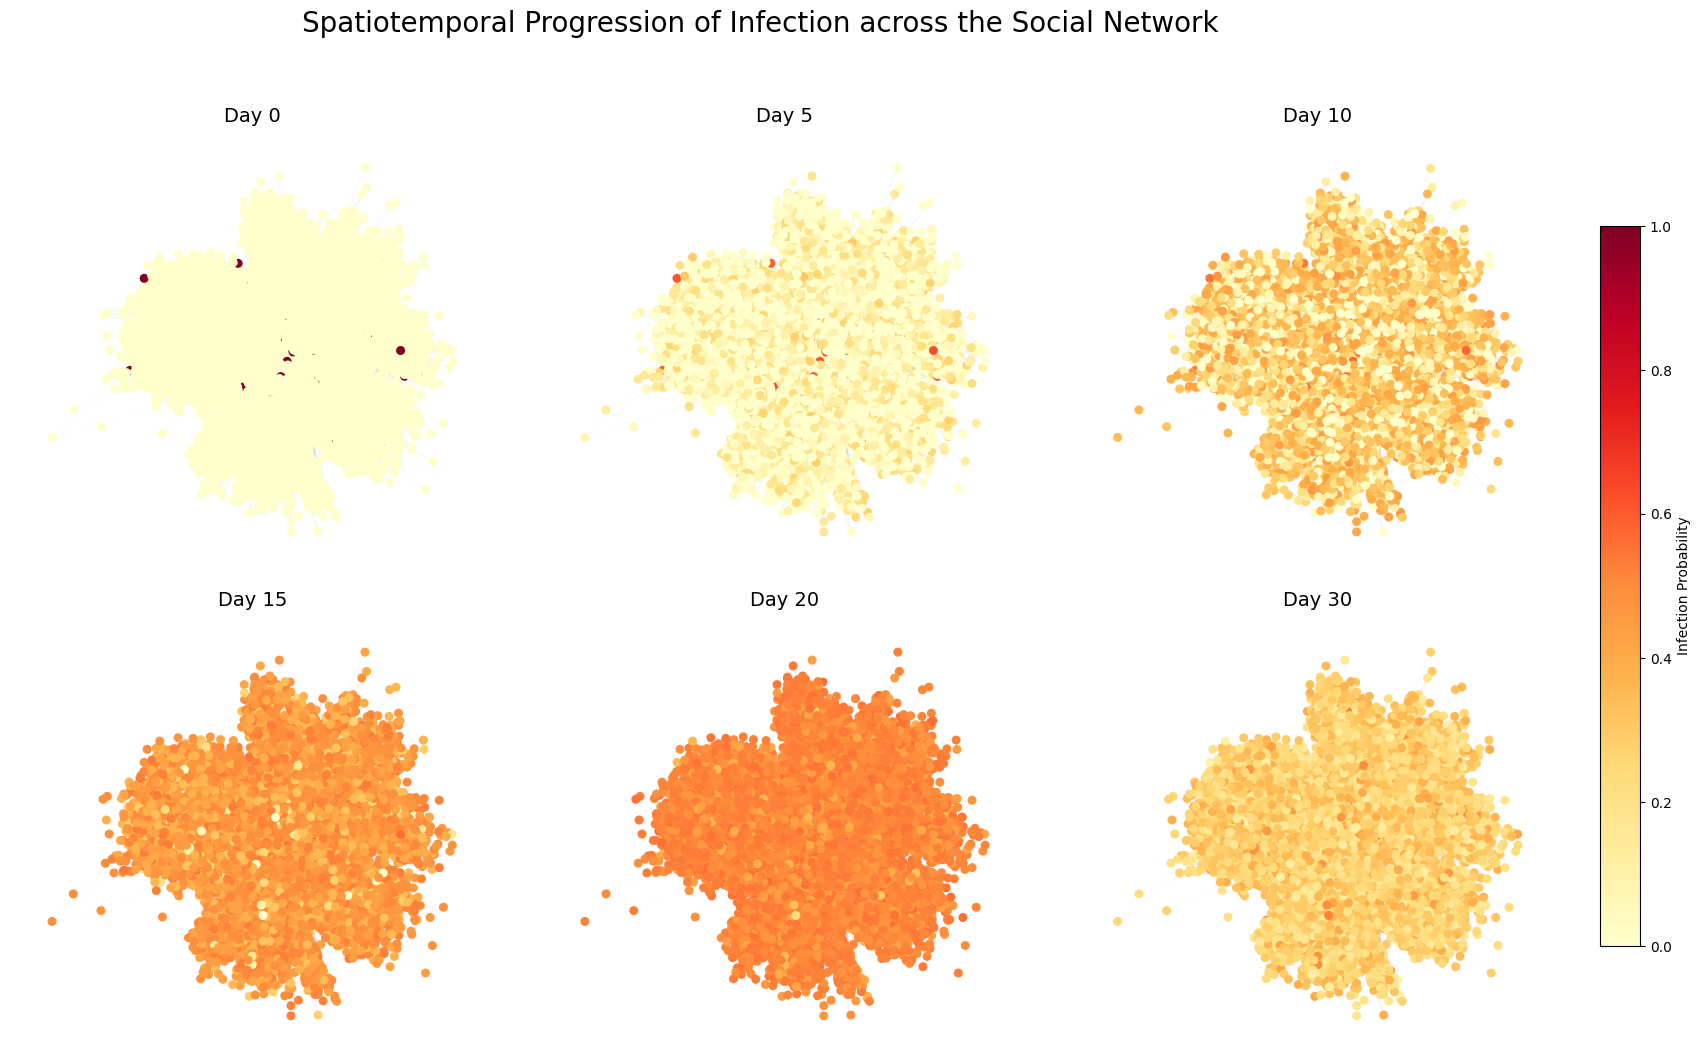

In [46]:
import networkx as nx
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration
# Days we want to visualize (0 is initial state, then steps through rollout)
target_days = [0, 5, 10, 15, 20, 30]
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# 2. Extract Data
sample = test_pairs[0]
g_data = graphs[sample['graph_seed']]
edge_index = g_data['edge_index']
x0 = sample['x0'].to(device)

with torch.no_grad():
    # pred is (30, nodes, 5) representing days 1-30
    pred = model.rollout(x0, g_data['node_feats'], edge_index, g_data['edge_attr'], n_days=30)

# 3. Create Graph and Fixed Layout
G = nx.Graph()
G.add_edges_from(edge_index.cpu().numpy().T)
# Fixed layout ensures nodes stay in the same place across all panels
pos = nx.spring_layout(G, k=0.15, seed=42) 

# 4. Loop through days and plot
for i, day in enumerate(target_days):
    ax = axes[i]
    
    # Get infection probability for this day
    if day == 0:
        inf_data = x0[:, 2].cpu().numpy() # Day 0 comes from initial state
    else:
        inf_data = pred[day-1, :, 2].cpu().numpy() # Days 1-30 from prediction
    
    # Draw Nodes
    nodes = nx.draw_networkx_nodes(G, pos, 
                                   node_size=30, 
                                   node_color=inf_data, 
                                   cmap='YlOrRd', 
                                   ax=ax,
                                   vmin=0, vmax=1.0) # Consistent scale
    
    # Draw Edges (very faint)
    nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.05, edge_color='gray', ax=ax)
    
    ax.set_title(f"Day {day}", fontsize=14)
    ax.axis('off')

# Add a single colorbar for the whole figure
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
fig.colorbar(nodes, cax=cbar_ax, label='Infection Probability')

plt.suptitle("Spatiotemporal Progression of Infection across the Social Network", fontsize=20)
plt.subplots_adjust(right=0.9, wspace=0.1, hspace=0.1)
plt.savefig('epidemic_progression_grid.png', dpi=300, bbox_inches='tight')
plt.show()

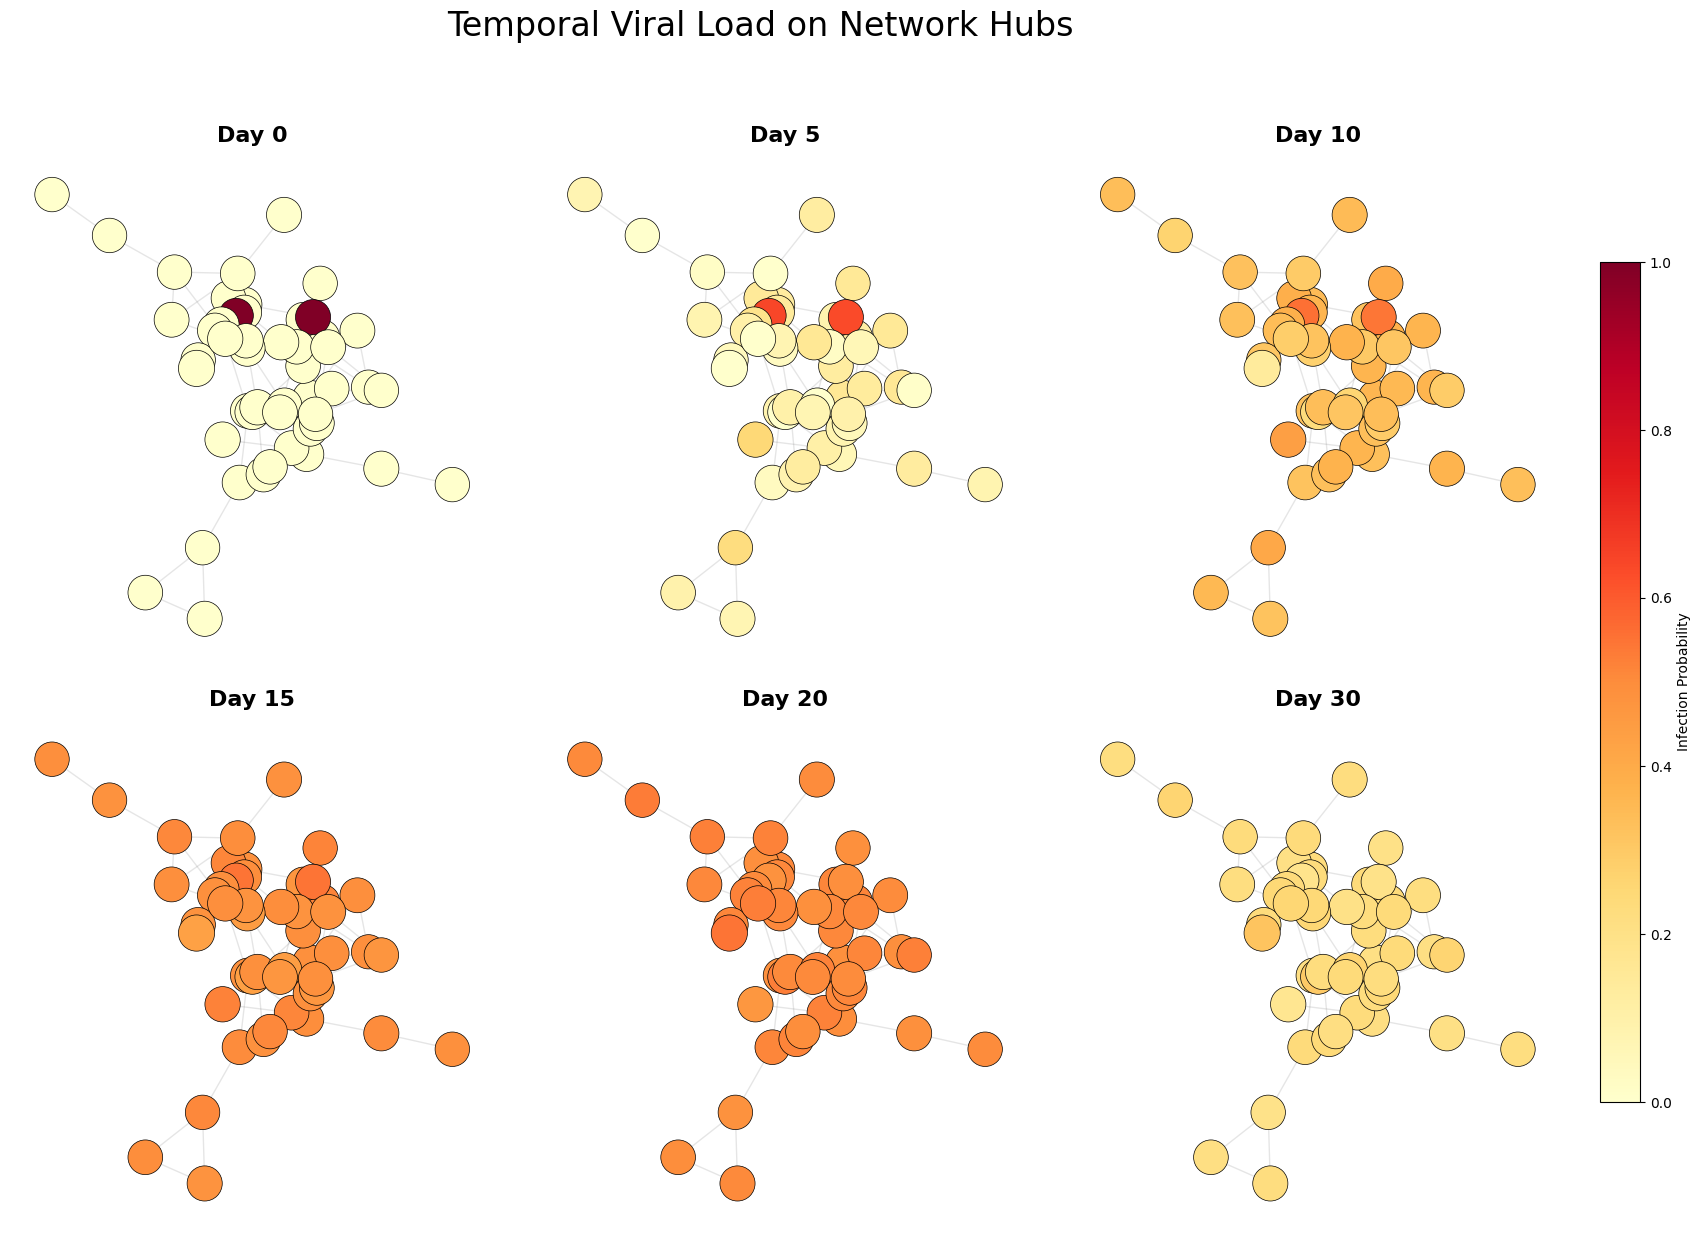

In [47]:
import networkx as nx
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup - 6 significant days for the progression
target_days = [0, 5, 10, 15, 20, 30]
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

# 2. Extract Data
sample = test_pairs[0]
g_data = graphs[sample['graph_seed']]
edge_index = g_data['edge_index']
x0 = sample['x0'].to(device)

with torch.no_grad():
    # pred is (30, nodes, 5) representing days 1-30
    pred = model.rollout(x0, g_data['node_feats'], edge_index, g_data['edge_attr'], n_days=30)

# 3. Graph Processing for Hubs
G = nx.Graph()
G.add_edges_from(edge_index.cpu().numpy().T)
degrees = dict(G.degree())

# Extract top 50 hubs
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:50]
S = G.subgraph(top_nodes)

# Use Kamada-Kawai layout for the hubs - it handles small core groups beautifully
pos_sub = nx.kamada_kawai_layout(S)

# 4. Temporal Loop
for i, day in enumerate(target_days):
    ax = axes[i]
    
    # Get infection data for all nodes, then filter for hubs
    if day == 0:
        full_inf_data = x0[:, 2].cpu().numpy()
    else:
        full_inf_data = pred[day-1, :, 2].cpu().numpy()
        
    hub_inf_data = [full_inf_data[n] for n in S.nodes()]
    
    # Draw Nodes: Sized by their degree in the FULL graph
    # This visually distinguishes the "Major Hubs" from "Minor Hubs"
    node_sizes = [degrees[n] * 8 for n in S.nodes()]
    
    nodes = nx.draw_networkx_nodes(S, pos_sub, 
                                   node_size=node_sizes, 
                                   node_color=hub_inf_data, 
                                   cmap='YlOrRd', 
                                   ax=ax,
                                   vmin=0, vmax=1.0,
                                   edgecolors='black', linewidths=0.5)
    
    # Draw edges between hubs
    nx.draw_networkx_edges(S, pos_sub, width=1.0, alpha=0.2, edge_color='gray', ax=ax)
    
    ax.set_title(f"Day {day}", fontsize=16, fontweight='bold')
    ax.axis('off')

# 5. Styling and Saving
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
fig.colorbar(nodes, cax=cbar_ax, label='Infection Probability')

plt.suptitle("Temporal Viral Load on Network Hubs", fontsize=24, y=0.98)
plt.subplots_adjust(right=0.9, wspace=0.1, hspace=0.1)

# Save for the paper
plt.savefig(f'{BASE}/hub_progression_6panel.png', dpi=300, bbox_inches='tight')
plt.show()

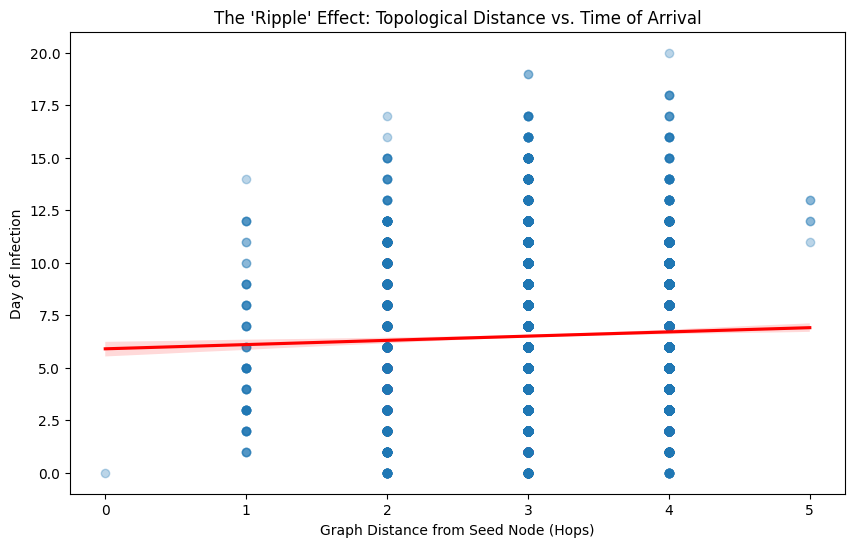

In [49]:
# 1. Identify the starting node (where x0 has the highest infection)
seed_node = torch.argmax(x0[:, 2]).item()

# 2. Calculate shortest path distance from seed to all other nodes
distances = nx.single_source_shortest_path_length(G, seed_node)

# 3. Get 'Arrival Day' for each node (from your previous logic)
arrival_days = []
topo_distances = []

for node_idx in range(pred.shape[1]):
    curve = pred[:, node_idx, 2].cpu().numpy()
    arrivals = np.where(curve > 0.1)[0]
    if len(arrivals) > 0:
        arrival_days.append(arrivals[0])
        topo_distances.append(distances.get(node_idx, 0))

# 4. Plot
plt.figure(figsize=(10, 6))
sns.regplot(x=topo_distances, y=arrival_days, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("The 'Ripple' Effect: Topological Distance vs. Time of Arrival")
plt.xlabel("Graph Distance from Seed Node (Hops)")
plt.ylabel("Day of Infection")
plt.savefig(f'{BASE}/ripple_effect.png', dpi=300, bbox_inches='tight')
plt.show()

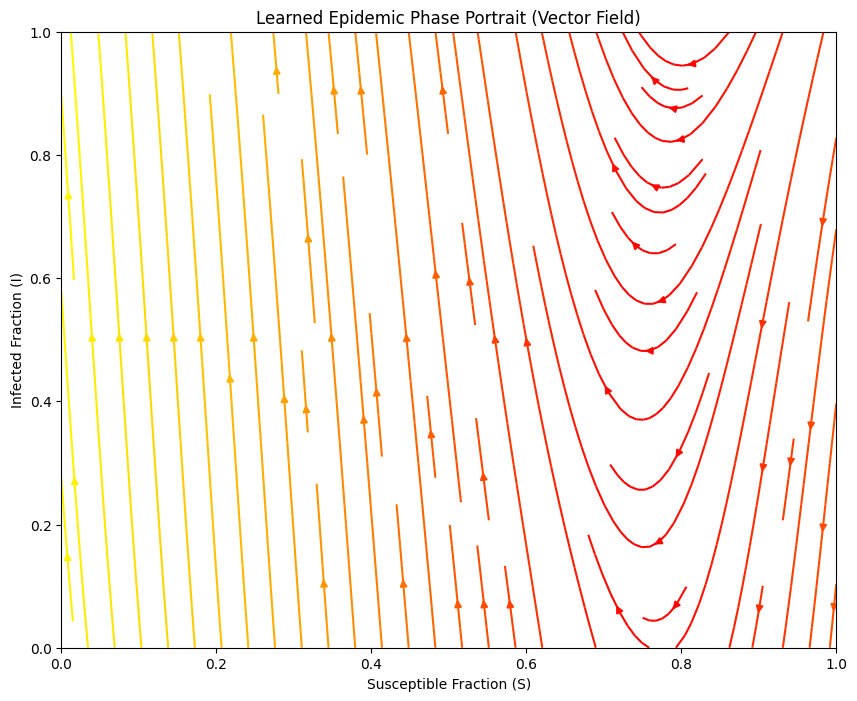

In [51]:
# Create a grid of S and I values
s_grid, i_grid = np.meshgrid(np.linspace(0, 1, 20), np.linspace(0, 1, 20))
u = np.zeros_like(s_grid) # dS/dt
v = np.zeros_like(i_grid) # dI/dt

# We use the model to predict the 'force' at each point in the grid
model.eval()
with torch.no_grad():
    for i in range(20):
        for j in range(20):
            # Create a dummy state for a single node [S, E, I, R, D]
            test_state = torch.tensor([[s_grid[i,j], 0, i_grid[i,j], 1-s_grid[i,j]-i_grid[i,j], 0]]).to(device)
            # Get the derivative (dxdt) from the model
            # Note: We use a dummy graph context for a single node point
            model.ode_func.set_graph(torch.zeros((1,9)).to(device), 
                                     torch.tensor([[0],[0]]).to(device), 
                                     torch.zeros((1,1)).to(device))
            dxdt = model.ode_func(0, test_state)
            u[i,j] = dxdt[0, 0].cpu().item() # dS
            v[i,j] = dxdt[0, 2].cpu().item() # dI

plt.figure(figsize=(10, 8))
plt.streamplot(s_grid, i_grid, u, v, color=np.sqrt(u**2 + v**2), cmap='autumn')
plt.xlabel('Susceptible Fraction (S)')
plt.ylabel('Infected Fraction (I)')
plt.title('Learned Epidemic Phase Portrait (Vector Field)')
plt.savefig(f'{BASE}/vector_field.png', dpi=300, bbox_inches='tight')
plt.show()

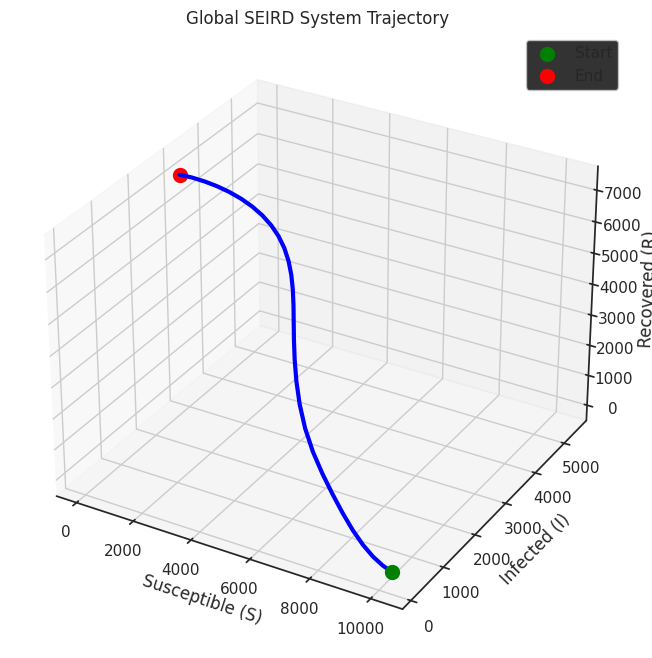

In [55]:
from mpl_toolkits.mplot3d import Axes3D

S_total = pred[:, :, 0].sum(dim=1).cpu()
I_total = pred[:, :, 2].sum(dim=1).cpu()
R_total = pred[:, :, 3].sum(dim=1).cpu()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(S_total, I_total, R_total, lw=3, color='blue')
ax.scatter(S_total[0], I_total[0], R_total[0], color='green', s=100, label='Start')
ax.scatter(S_total[-1], I_total[-1], R_total[-1], color='red', s=100, label='End')

ax.set_xlabel('Susceptible (S)')
ax.set_ylabel('Infected (I)')
ax.set_zlabel('Recovered (R)')
plt.title("Global SEIRD System Trajectory")
plt.legend()
plt.savefig(f'{BASE}/global_sierd_system_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

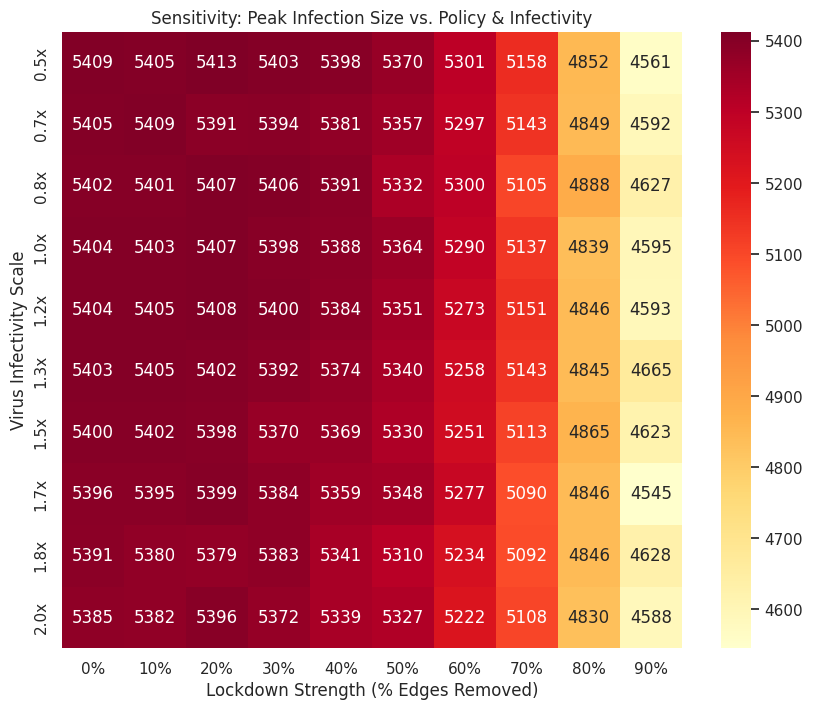

In [56]:
# 1. Setup range of values
transmission_scales = np.linspace(0.5, 2.0, 10) # 0.5x to 2.0x infectivity
lockdown_strengths = np.linspace(0.0, 0.9, 10)  # 0% to 90% edge removal

peak_matrix = np.zeros((10, 10))

# 2. Run the "Grid Search" (very fast with rollout!)
with torch.no_grad():
    for i, t_scale in enumerate(transmission_scales):
        for j, l_strength in enumerate(lockdown_strengths):
            # Apply lockdown (random edge removal)
            num_edges = edge_index.shape[1]
            keep_mask = torch.rand(num_edges, device=device) > l_strength
            ei_sub = edge_index[:, keep_mask]
            # Scale transmission
            ea_sub = edge_attr[keep_mask] * t_scale
            
            # Rollout
            p = model.rollout(x0, node_feats, ei_sub, ea_sub, n_days=30)
            peak_matrix[i, j] = p[:, :, 2].sum(dim=1).max().item()

# 3. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(peak_matrix, annot=True, fmt=".0f", 
            xticklabels=[f"{int(x*100)}%" for x in lockdown_strengths],
            yticklabels=[f"{x:.1f}x" for x in transmission_scales],
            cmap="YlOrRd")
plt.title("Sensitivity: Peak Infection Size vs. Policy & Infectivity")
plt.xlabel("Lockdown Strength (% Edges Removed)")
plt.ylabel("Virus Infectivity Scale")
plt.savefig(f'{BASE}/sensitivity_heatmap.png', dpi=300)
plt.show()

=== NOVEL SEEDING TEST ===
Seeding with bottom-degree nodes on an unseen graph.
Model has NEVER seen this combination. If it predicts spread, it generalizes.



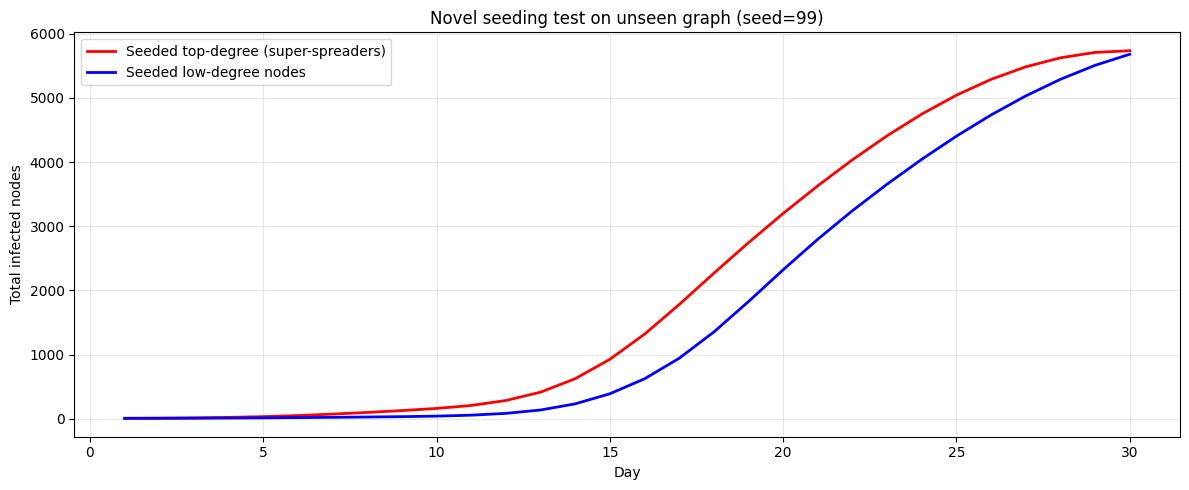

Top-degree seeding peak: 5736 nodes on day 30
Low-degree seeding peak: 5681 nodes on day 30

GOOD: super-spreader seeding causes more infections than low-degree seeding.
      Model has learned that high-connectivity nodes spread more.


In [29]:
# Cell 17 — CRITICAL: test on a completely new seeding scenario
# This is the real test: give the model seeds it NEVER saw, on a graph it NEVER saw
# If it still predicts spread, the model learned dynamics

print('=== NOVEL SEEDING TEST ===')
print('Seeding with bottom-degree nodes on an unseen graph.')
print('Model has NEVER seen this combination. If it predicts spread, it generalizes.\n')

gseed = 99  # unseen test graph
g     = graphs[gseed]

src_g = g['edge_index'][0]
deg   = torch.zeros(g['N'], dtype=torch.long, device=device)
deg.scatter_add_(0, src_g, torch.ones(src_g.shape[0], dtype=torch.long, device=device))

# Scenario A: seed top-degree (super-spreaders)
top_seeds = torch.topk(deg.float(), k=5).indices
x0_top = torch.zeros(g['N'], 5, device=device)
x0_top[:, 0] = 1.0
for nid in top_seeds: x0_top[nid, 0]=0; x0_top[nid, 2]=1

# Scenario B: seed low-degree nodes
bot_seeds = torch.topk(-deg.float(), k=5).indices
x0_bot = torch.zeros(g['N'], 5, device=device)
x0_bot[:, 0] = 1.0
for nid in bot_seeds: x0_bot[nid, 0]=0; x0_bot[nid, 2]=1

with torch.no_grad():
    pred_top = model.rollout(x0_top, g['node_feats'], g['edge_index'], g['edge_attr'], n_days=30, tf_prob=0.0)
    pred_bot = model.rollout(x0_bot, g['node_feats'], g['edge_index'], g['edge_attr'], n_days=30, tf_prob=0.0)

I_top = pred_top[:, :, 2].sum(dim=1).cpu()
I_bot = pred_bot[:, :, 2].sum(dim=1).cpu()

plt.figure(figsize=(12, 5))
plt.plot(range(1,31), I_top.numpy(), label='Seeded top-degree (super-spreaders)', color='red',  linewidth=2)
plt.plot(range(1,31), I_bot.numpy(), label='Seeded low-degree nodes',              color='blue', linewidth=2)
plt.xlabel('Day'); plt.ylabel('Total infected nodes')
plt.title(f'Novel seeding test on unseen graph (seed={gseed})')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/novel_seeding_test.png', dpi=150)
plt.show()

print(f'Top-degree seeding peak: {I_top.max():.0f} nodes on day {I_top.argmax().item()+1}')
print(f'Low-degree seeding peak: {I_bot.max():.0f} nodes on day {I_bot.argmax().item()+1}')
print()
if I_top.max() > I_bot.max():
    print('GOOD: super-spreader seeding causes more infections than low-degree seeding.')
    print('      Model has learned that high-connectivity nodes spread more.')
else:
    print('WARNING: model does not distinguish seeding strategy.')
    print('         Consider more training epochs or more graph diversity.')

In [36]:
import time

start_time = time.time()
with torch.no_grad():
    _ = model.rollout(x0, node_feats, edge_index, edge_attr, n_days=30)
end_time = time.time()

print(f"Inference Time for 30-day forecast: {end_time - start_time:.4f} seconds")

Inference Time for 30-day forecast: 2.3919 seconds


In [27]:
import torch
import numpy as np

def calculate_full_seird_accuracy(model, test_pairs, graphs):
    model.eval()
    
    # Names of the compartments in order of their indices [0, 1, 2, 3, 4]
    state_names = ['Susceptible', 'Exposed', 'Infected', 'Recovered', 'Dead']
    
    # Dictionary to store MAE for each state across all test samples
    state_maes = {name: [] for name in state_names}
    
    print(f"Calculating full SEIRD accuracy for {len(test_pairs)} test sequences...")
    
    with torch.no_grad():
        for p in test_pairs:
            g = graphs[p['graph_seed']]
            x0 = p['x0'].to(device)
            y_true = p['y'].to(device) # Shape: (days, nodes, 5)
            
            # Predict the trajectory
            y_pred = model.rollout(
                x0, g['node_feats'], g['edge_index'], g['edge_attr'], 
                n_days=30
            )
            
            # Calculate MAE for each compartment individually
            for i, name in enumerate(state_names):
                # Calculate absolute error for this specific state index
                mae = torch.abs(y_pred[:, :, i] - y_true[:, :, i]).mean().item()
                state_maes[name].append(mae)
                
    print("\n" + "="*45)
    print(f"{'STATE':<15} | {'MAE':<10} | {'ACCURACY':<10}")
    print("-" * 45)
    
    total_acc = 0
    for name in state_names:
        avg_mae = np.mean(state_maes[name])
        accuracy = (1.0 - avg_mae) * 100
        total_acc += accuracy
        print(f"{name:<15} | {avg_mae:.4f}     | {accuracy:.2f}%")
    
    overall_avg_acc = total_acc / len(state_names)
    print("-" * 45)
    print(f"{'OVERALL AVG':<15} |           | {overall_avg_acc:.2f}%")
    print("="*45)
    
    return state_maes

# Execute the analysis
seird_results = calculate_full_seird_accuracy(model, test_pairs, graphs)

Calculating full SEIRD accuracy for 15 test sequences...

STATE           | MAE        | ACCURACY  
---------------------------------------------
Susceptible     | 0.1002     | 89.98%
Exposed         | 0.0671     | 93.29%
Infected        | 0.0525     | 94.75%
Recovered       | 0.0382     | 96.18%
Dead            | 0.0192     | 98.08%
---------------------------------------------
OVERALL AVG     |           | 94.46%


In [17]:
# Cell 15 — Full accuracy evaluation for research report
print('=' * 60)
print('ACCURACY METRICS — TEST SET (unseen graphs)')
print('=' * 60)

model.load_state_dict(torch.load(f'{BASE}/model/tgn_best.pt', map_location=device))
model.eval()

results = []

for p in test_pairs:
    gseed = p['graph_seed']
    g     = graphs[gseed]
    x0    = p['x0'].to(device)
    y     = p['y'].to(device)    # (30, N, 5) ground truth
    N_g   = g['N']

    with torch.no_grad():
        pred = model.rollout(
            x0, g['node_feats'], g['edge_index'], g['edge_attr'],
            n_days=30, tf_prob=0.0
        )  # (30, N, 5)

    pred_cpu = pred.cpu()
    true_cpu = y.cpu()

    # --- Node-level metrics ---
    # MAE on I state across all nodes and days
    mae_I = (pred_cpu[:,:,2] - true_cpu[:,:,2]).abs().mean().item()
    mae_S = (pred_cpu[:,:,0] - true_cpu[:,:,0]).abs().mean().item()
    mae_R = (pred_cpu[:,:,3] - true_cpu[:,:,3]).abs().mean().item()

    # RMSE on I state
    rmse_I = ((pred_cpu[:,:,2] - true_cpu[:,:,2])**2).mean().sqrt().item()

    # Node-level classification accuracy: is the dominant state correct?
    pred_class = pred_cpu.argmax(dim=-1)   # (30, N)
    true_class = true_cpu.argmax(dim=-1)   # (30, N)
    node_accuracy = (pred_class == true_class).float().mean().item()

    # --- Population-level metrics ---
    pred_curve = pred_cpu[:,:,2].sum(dim=1) / N_g   # (30,) mean I fraction
    true_curve = true_cpu[:,:,2].sum(dim=1) / N_g   # (30,)

    # Peak I magnitude
    pred_peak_mag = pred_curve.max().item()
    true_peak_mag = true_curve.max().item()
    peak_mag_err  = abs(pred_peak_mag - true_peak_mag)

    # Peak I timing
    pred_peak_day = pred_curve.argmax().item() + 1
    true_peak_day = true_curve.argmax().item() + 1
    peak_day_err  = abs(pred_peak_day - true_peak_day)

    # Pearson correlation of the I curves
    pc = true_curve - true_curve.mean()
    qc = pred_curve - pred_curve.mean()
    corr = (pc * qc).sum() / (pc.norm() * qc.norm() + 1e-8)
    pearson = corr.item()

    # MAPE on I curve (Mean Absolute Percentage Error)
    mape = ((true_curve - pred_curve).abs() / (true_curve + 1e-6)).mean().item() * 100

    # R-squared on I curve
    ss_res = ((true_curve - pred_curve)**2).sum().item()
    ss_tot = ((true_curve - true_curve.mean())**2).sum().item()
    r2 = 1 - ss_res / (ss_tot + 1e-8)

    results.append({
        'graph_seed':    gseed,
        'sim_idx':       p['sim_idx'],
        'mae_I':         mae_I,
        'mae_S':         mae_S,
        'mae_R':         mae_R,
        'rmse_I':        rmse_I,
        'node_accuracy': node_accuracy,
        'peak_mag_err':  peak_mag_err,
        'peak_day_err':  peak_day_err,
        'pearson':       pearson,
        'mape':          mape,
        'r2':            r2,
        'pred_peak_day': pred_peak_day,
        'true_peak_day': true_peak_day,
        'pred_peak_mag': pred_peak_mag,
        'true_peak_mag': true_peak_mag,
    })

    torch.cuda.empty_cache()

# --- Print per-pair results ---
print(f'\n{"Seed":>5} {"Sim":>4} {"MAE_I":>7} {"RMSE_I":>7} '
      f'{"NodeAcc":>8} {"PkDay":>6} {"PkMag":>6} {"R²":>6} {"Pearson":>8}')
print('-' * 70)
for r in results:
    print(f'{r["graph_seed"]:>5} {r["sim_idx"]:>4} '
          f'{r["mae_I"]:>7.4f} {r["rmse_I"]:>7.4f} '
          f'{r["node_accuracy"]:>8.3f} '
          f'{r["peak_day_err"]:>6.1f} {r["peak_mag_err"]:>6.3f} '
          f'{r["r2"]:>6.3f} {r["pearson"]:>8.4f}')

# --- Summary statistics ---
import numpy as np

print('\n' + '=' * 60)
print('SUMMARY (mean ± std across test pairs)')
print('=' * 60)
metrics = {
    'MAE on I state':              [r['mae_I']         for r in results],
    'RMSE on I state':             [r['rmse_I']        for r in results],
    'Node-level accuracy':         [r['node_accuracy'] for r in results],
    'Peak day error (days)':       [r['peak_day_err']  for r in results],
    'Peak magnitude error':        [r['peak_mag_err']  for r in results],
    'R² on I curve':               [r['r2']            for r in results],
    'Pearson r on I curve':        [r['pearson']       for r in results],
    'MAPE on I curve (%)':         [r['mape']          for r in results],
}

for name, vals in metrics.items():
    print(f'  {name:<30}: {np.mean(vals):.4f} ± {np.std(vals):.4f}')

# --- Save to JSON for paper ---
import json
summary = {k: {'mean': float(np.mean(v)), 'std': float(np.std(v))}
           for k, v in metrics.items()}
with open(f'{BASE}/accuracy_metrics.json', 'w') as f:
    json.dump({'per_pair': results, 'summary': summary}, f, indent=2)
print(f'\nFull metrics saved to {BASE}/accuracy_metrics.json')

ACCURACY METRICS — TEST SET (unseen graphs)

 Seed  Sim   MAE_I  RMSE_I  NodeAcc  PkDay  PkMag     R²  Pearson
----------------------------------------------------------------------
   88    0  0.0459  0.0660    0.805    1.0  0.009  0.987   0.9960
   88    1  0.0459  0.0672    0.800    2.0  0.005  0.987   0.9941
   88    2  0.0434  0.0696    0.840    3.0  0.002  0.988   0.9943
   88    3  0.0430  0.0742    0.851    1.0  0.004  0.989   0.9987
   88    4  0.0532  0.0802    0.779    3.0  0.003  0.961   0.9822
   99    0  0.0539  0.0824    0.807    0.0  0.029  0.935   0.9855
   99    1  0.0494  0.0796    0.813    0.0  0.029  0.947   0.9908
   99    2  0.0529  0.0900    0.815    2.0  0.038  0.906   0.9893
   99    3  0.0770  0.1325    0.779    0.0  0.083  0.196   0.9371
   99    4  0.0493  0.0823    0.813    0.0  0.031  0.955   0.9940
  111    0  0.0538  0.0807    0.809    0.0  0.022  0.945   0.9816
  111    1  0.0491  0.0774    0.814    0.0  0.018  0.965   0.9922
  111    2  0.0710  0.1193

In [23]:
# Cell 18 — Save outputs
import shutil
shutil.copy(f'{BASE}/model/tgn_best.pt',       f'{BASE}/tgn_best.pt')
shutil.copy(f'{BASE}/training_curve.png',       f'{BASE}/training_curve_1.png')
# shutil.copy(f'{BASE}/test_prediction.png',      f'{BASE}/test_prediction_1.png')
# shutil.copy(f'{BASE}/novel_seeding_test.png',   f'{BASE}/novel_seeding_test.png')

print('Output files:')
for f in os.listdir(BASE):
    if not os.path.isdir(f'{BASE}/{f}'):
        mb = os.path.getsize(f'{BASE}/{f}') / 1e6
        print(f'  {f}  ({mb:.1f} MB)')

print('\nDownload tgn_best.pt and promote to a Kaggle dataset called epidemic-model.')

Output files:
  training_curve_1.png  (0.1 MB)
  training_curve.png  (0.1 MB)
  tgn_best.pt  (0.1 MB)
  accuracy_metrics.json  (0.0 MB)
  paper_figure_prediction.png  (0.2 MB)
  novel_seeding_test.png  (0.1 MB)

Download tgn_best.pt and promote to a Kaggle dataset called epidemic-model.
